In [2]:
import math 
class Value:
    def __init__(self,data, _children=() , _op='' , label=''):
        self.data=data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out=Value(self.data + other.data , (self,other), '+')

    #chain rule inside add 
        def _backward():
          self.grad = 1.0 * out.grad
          other.grad = 1.0 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self,other):
        out=Value(self.data * other.data ,(self,other), '*')
        
#chain rule inside multiplication
        def _backward():
          self.grad = other.data * out.grad
          other.grad = self.data * out.grad
        out._backward = _backward
      
        return out
       
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
#chain rule inside the tanh function 
        def _backward():
           self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
           if v not in visited:
             visited.add(v)
             for child in v._prev:
               build_topo(child)
               topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
               node._backward()



a = Value(2.0 , label='a')
b = Value(-3.0 , label='b')
c = Value(10.0 , label='c')
e = a*b; e.label = 'e'
d = e+c ; d.label ='d'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
d

Value(data=4.0)

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label_str = getattr(n, 'label', 'no label')
        data_val = getattr(n, 'data', 0.0)
        grad_val = getattr(n, 'grad', 0.0)
        op_str = getattr(n, '_op', '')
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (label_str, data_val, grad_val), shape='record')
        #dot.node(name=uid, label="{ %s | data %.4f  }" % (label_str, data_val), shape='record')
        if op_str:
            dot.node(name=uid + op_str, label=op_str)
            dot.edge(uid + op_str, uid)
    for n1, n2 in edges:
        op_str = getattr(n2, '_op', '')
        dot.edge(str(id(n1)), str(id(n2)) + op_str)
    return dot
    

# def draw_dot(root):
#   dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
#   nodes, edges = trace(root)
#   for n in nodes:
#     uid = str(id(n))
#     # for any value in the graph, create a rectangular ('record') node for it
#     dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
#     if n._op:
#       # if this value is a result of some operation, create an op node for it
#       dot.node(name = uid + n._op, label = n._op)
#       # and connect this node to it
#       dot.edge(uid + n._op, uid)

#   for n1, n2 in edges:
#     # connect n1 to the op node of n2
#     dot.edge(str(id(n1)), str(id(n2)) + n2._op)

#   return dot

In [4]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


In [5]:
o.grad=1.0

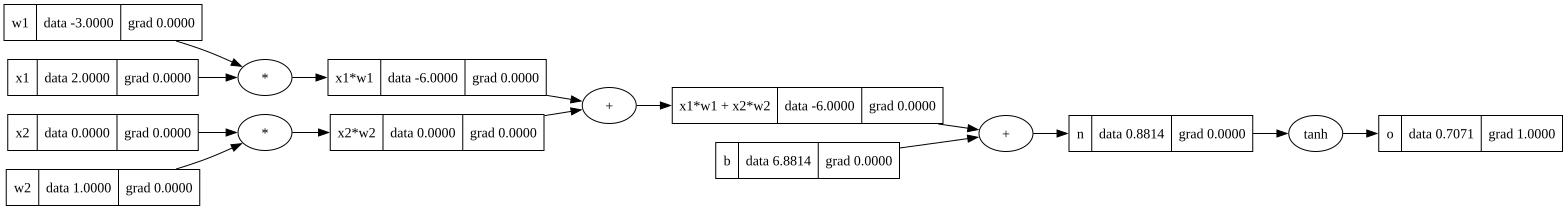

In [6]:
draw_dot(o)

In [7]:
o.backward()

In [8]:
o.grad=1.0
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()


In [9]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [10]:
o._backward()

In [11]:
n._backward()

In [12]:
b._backward()

In [13]:
x1w1x2w2._backward()

In [14]:
x2w2._backward()
x1w1._backward()

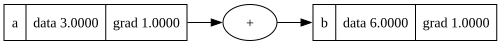

In [15]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)
#bug 
    # def __add__(self,other):
    #     out=Value(self.data + other.data , (self,other), '+')

    # #chain rule inside add 
    #     def _backward():
    #       self.grad = 1.0 * out.grad
    #       other.grad = 1.0 * out.grad  --> setting to one 
    #     out._backward = _backward
    #     return out
#A bug is identified when a variable is used more than once in an expression, 
# causing gradient overwrite issues in the backward pass. 
#     The problem arises because gradients are set instead of accumulated.
#     The solution is to accumulate gradients using += to sum contributions from multiple uses,
# ensuring correct total gradients for shared variables. This fix is tested and confirmed to produce correct gradients.

#solution 
    #chain rule inside add 
        # def _backward():
        #   self.grad += 1.0 * out.grad
        #   other.grad += 1.0 * out.grad

        
# #chain rule inside multiplication
#         def _backward():
#           self.grad += other.data * out.grad
#           other.grad += self.data * out.grad

       
        

        
# #chain rule inside the tanh function 
#         def _backward():
#            self.grad += (1 - t**2) * out.grad


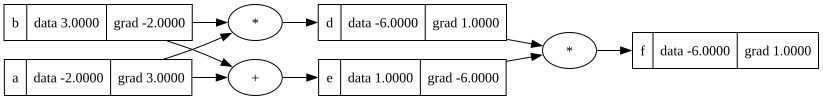

In [16]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)